In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
env_names = 'Habitat', 'iGibson'
df = {}
for env in env_names:
    data_reformatted = {}
    with open(f"model6{env.lower()}.json", "r") as file:
        data_json = json.load(file)
        for metric in data_json.keys():
            for model in data_json[metric].keys():
                new_key = (model, metric) if 'full' not in model else (model.replace('full', 'Full'), metric)
                data_reformatted[new_key] = data_json[metric][model]
    df[env] = pd.DataFrame(data_reformatted).stack(level=0, future_stack=True)
    df[env].index.set_names(['trial', 'model'], inplace=True)
    df[env].columns.set_names('metric', inplace=True)

In [3]:
env = 'newHabitat'
data_reformatted = {}
with open('model4newhabitat.json', "r") as file:
    data_json = json.load(file)
    for metric in data_json.keys():
        for model in data_json[metric].keys():
            new_key = (model, metric) if 'full' not in model else (model.replace('full', 'Full'), metric)
            data_reformatted[new_key] = data_json[metric][model]
df[env] = pd.DataFrame(data_reformatted).stack(level=0, future_stack=True)
df[env].index.set_names(['trial', 'model'], inplace=True)
df[env].columns.set_names('metric', inplace=True)

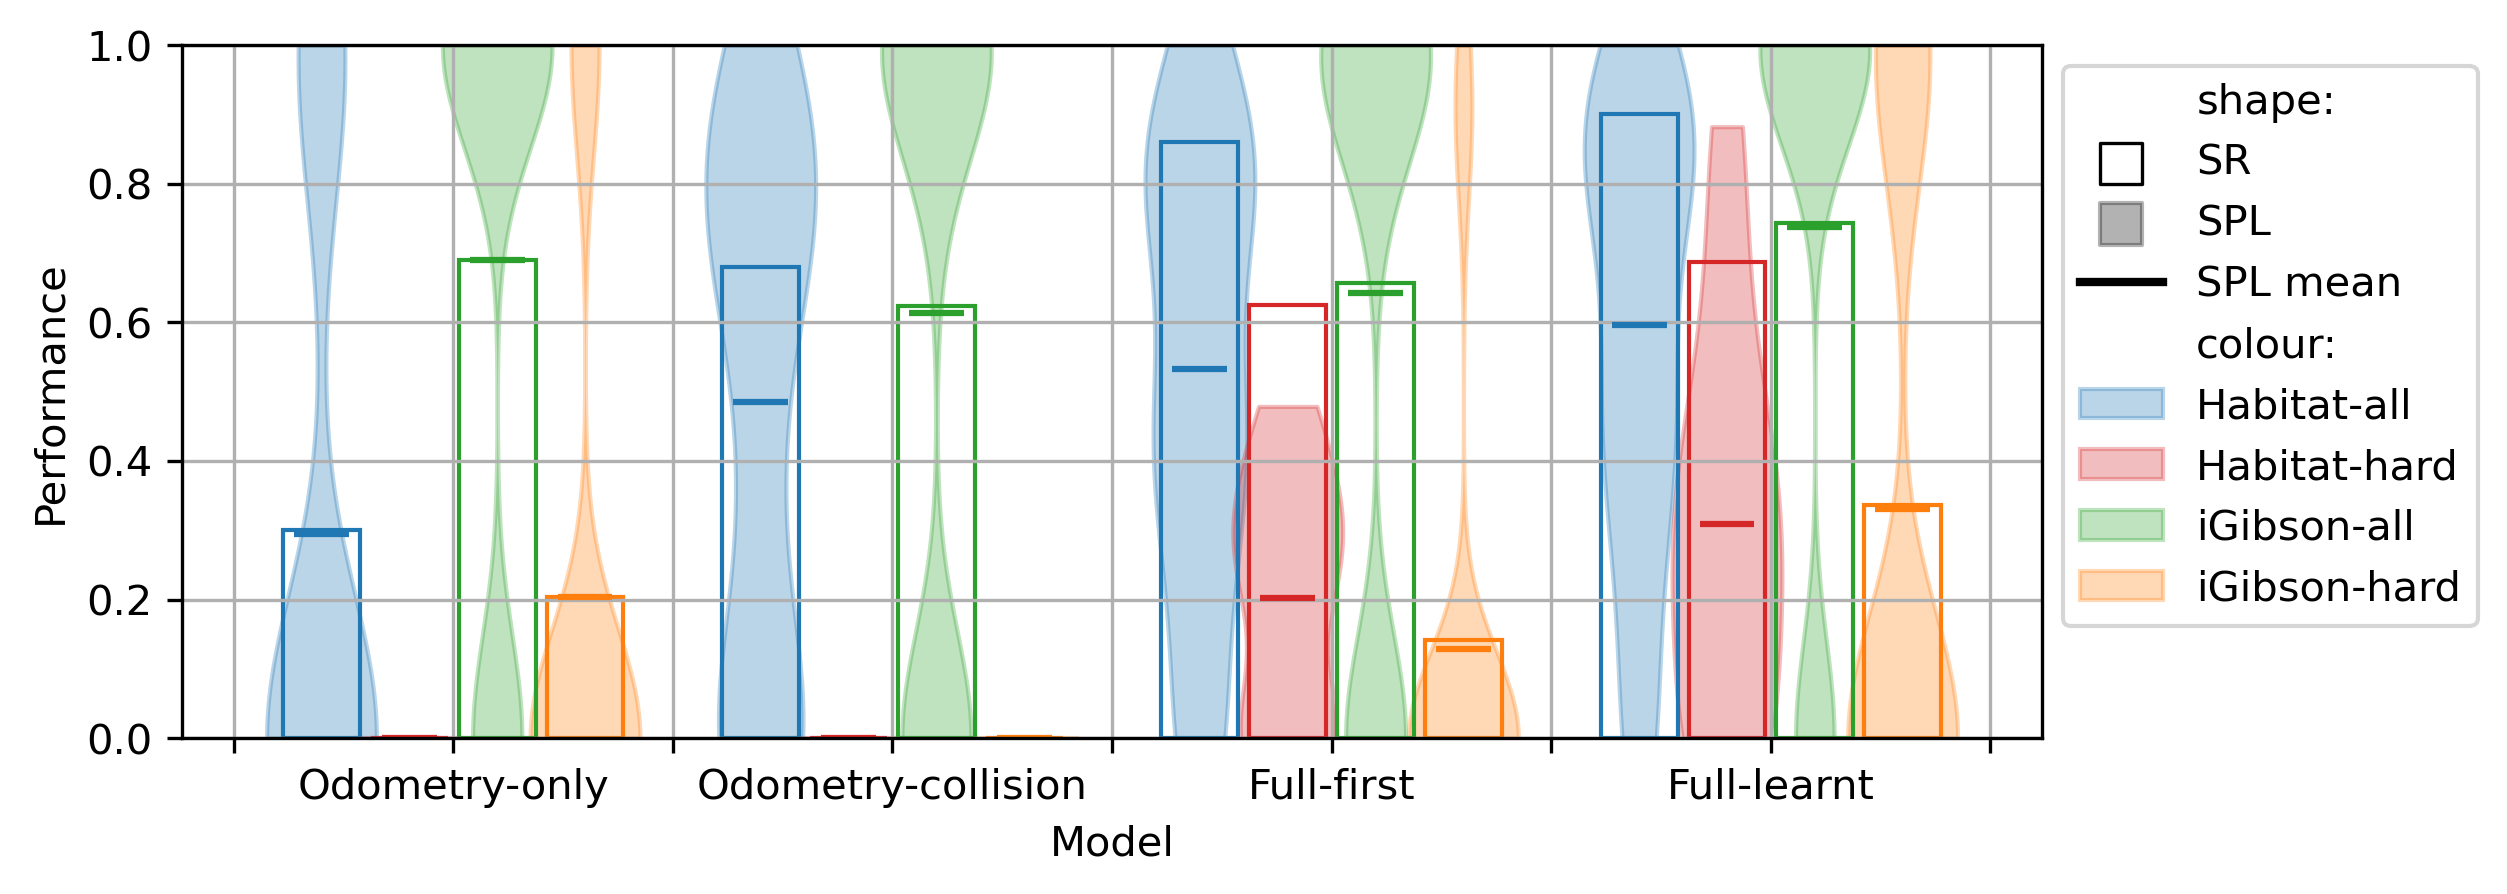

In [4]:
fig, axes = plt.subplots(figsize=(8, 3), dpi=300)

model_names = ['PI-only', 'PI+escape', 'Full-first', 'Full-learnt']
model_names_paper = ['Odometry-only', 'Odometry-collision', 'Full-first', 'Full-learnt']
colors = [['tab:blue', 'tab:red'], ['tab:green', 'tab:orange']]

n_model = len(model_names)
x0 = np.arange(n_model) * 2
xx = [[x0 - 0.6, x0 - 0.2], [x0 + 0.2, x0 + 0.6]]

for env, xe, ce in zip(['newHabitat', 'iGibson'], 
                       xx,
                       colors):
    spl, sr, spl_hard, sr_hard = [], [], [], []
    for model in model_names:
        model_spl = df[env]['spl'].loc[slice(None), model]
        model_sr = model_spl[model_spl > 0].count() / model_spl.count()

        is_hard = df[env]['spl'].loc[slice(None), 'PI+escape'] == 0
        hard_spl = model_spl[is_hard]
        hard_sr = hard_spl[hard_spl > 0].count() / hard_spl.count()
        
        spl.append(model_spl)
        sr.append(model_sr)
        spl_hard.append(hard_spl)
        sr_hard.append(hard_sr)

    for c, x, y in zip(ce, xe, [spl, spl_hard]):
        vp = axes.violinplot(y,
                             positions=x,
                             showextrema=False, 
                             showmeans=True)
        for part in vp['bodies']:
            part.set_facecolor(c)
            part.set_edgecolor(c)
        vp['cmeans'].set_edgecolor(c)
    for c, x, y in zip(ce, xe, [sr, sr_hard]):
        axes.bar(x, y,
                 width=0.35, 
                 fill=False, 
                 edgecolor=c
                )

xticks = np.insert(model_names_paper, np.arange(n_model + 1), '')
axes.set_xticks(np.arange(xticks.size) - 1, xticks)
axes.set_ylabel('Performance')
axes.set_xlabel('Model')
axes.set_ylim(0, 1)
axes.grid()

axes.scatter([], [], marker='None', label='shape:')
axes.scatter([], [], label='SR', facecolor='none', linewidth=0.8, edgecolor='k', marker='s', s=100)
axes.scatter([], [], label='SPL', color='k', alpha=0.3, marker='s', s=100)
axes.plot([], [], label='SPL mean', color='k', lw=2)
    
axes.scatter([], [], marker='None', label='colour:')
for ce, env in zip(colors, env_names):
    for c, epi in zip(ce, ['all', 'hard']):
        axes.fill_between([], [], [], [], color=c, alpha=0.3, label=f'{env}-{epi}')

axes.legend(ncol=1, loc='upper left', bbox_to_anchor=(1,1))

# plt.savefig("model-performance.pdf", format="pdf", bbox_inches="tight", dpi=300)

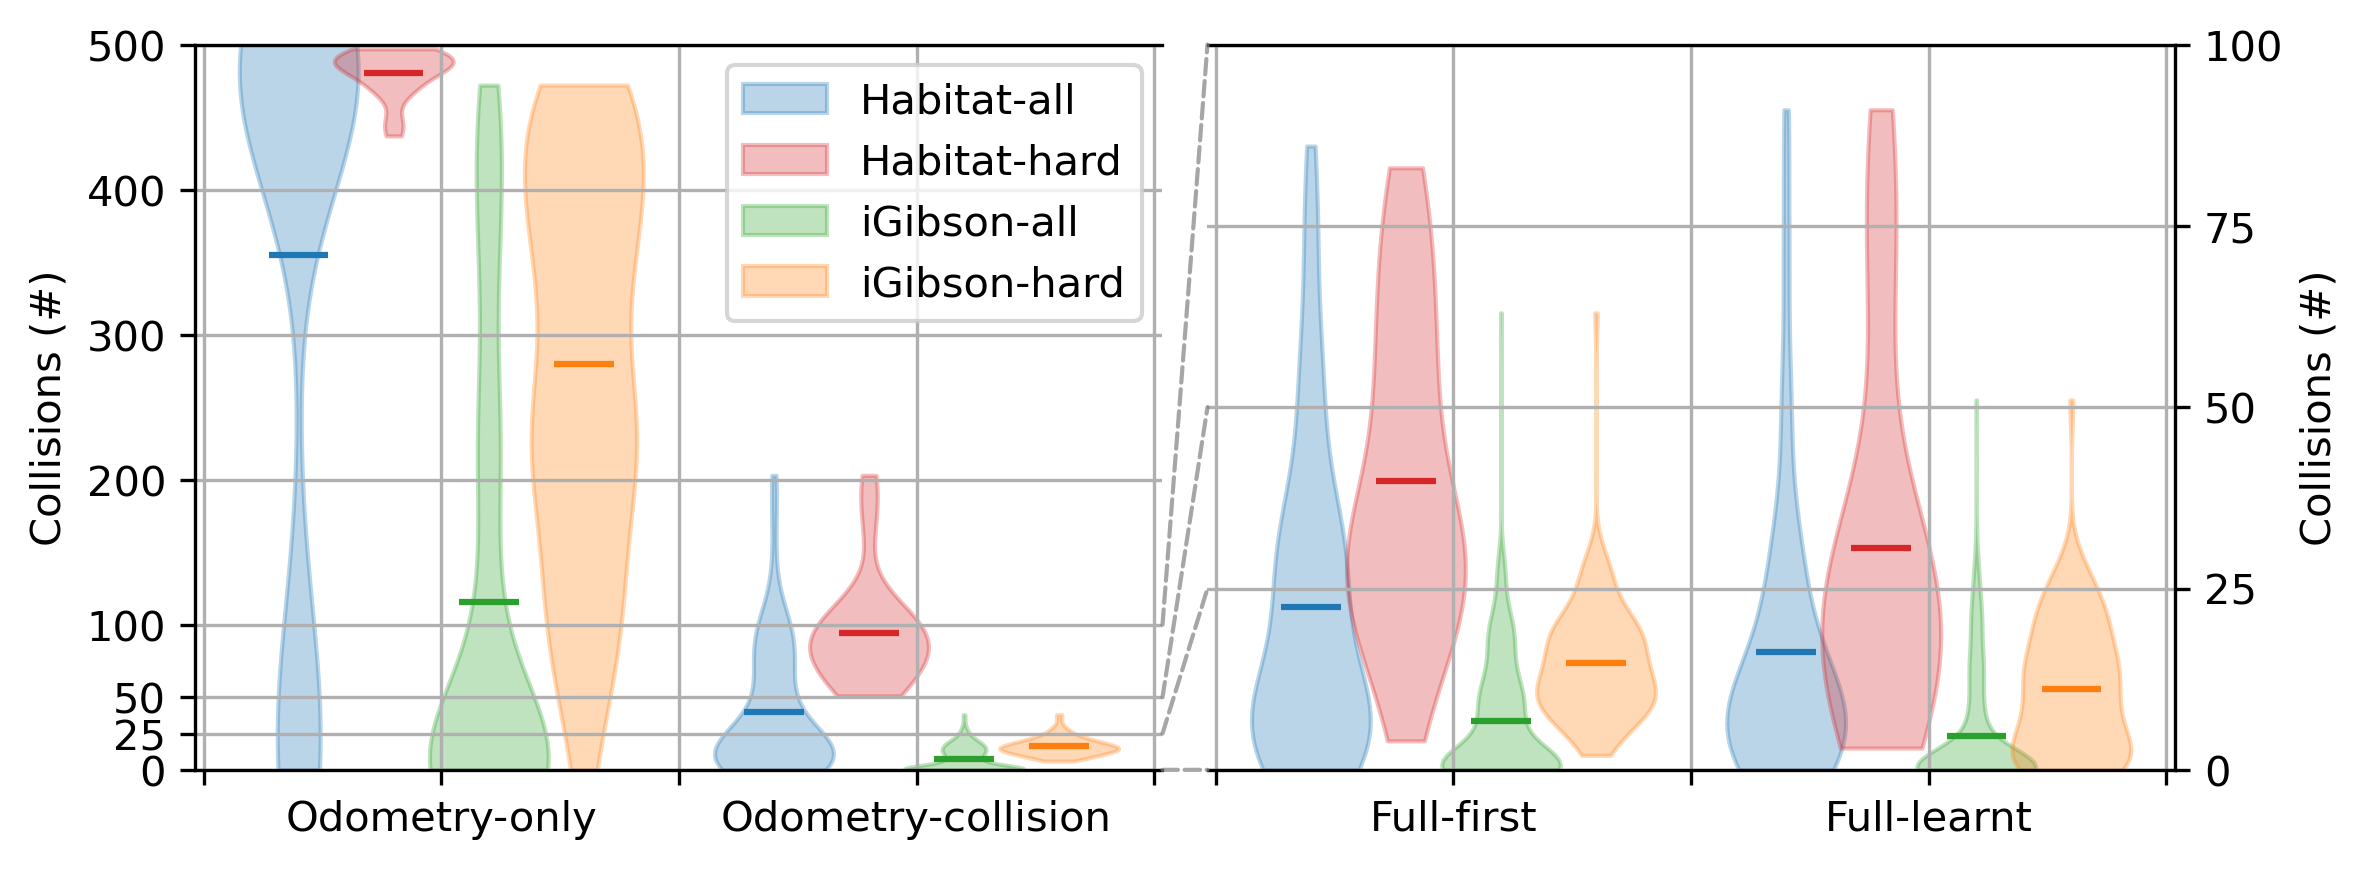

In [5]:
model_names = [['PI-only', 'PI+escape'], ['Full-first', 'Full-learnt']]
colors = [['tab:blue', 'tab:red'], ['tab:green', 'tab:orange']]

fig, axes = plt.subplots(1, 2, 
                         figsize=(8, 3), 
                         # gridspec_kw={'width_ratios': [1, 1]}, 
                         layout='tight',
                         dpi=300)

for ax, models, models_paper in zip(axes, model_names, np.reshape(model_names_paper, (2, 2))):
    n_model = len(models)
    x0 = np.arange(n_model) * 2
    xx = [[x0 - 0.6, x0 - 0.2], [x0 + 0.2, x0 + 0.6]]
    xticks = np.insert(models_paper, np.arange(n_model + 1), '')
    ax.set_xticks(np.arange(xticks.size) - 1, xticks)
    
    for env, xe, ce in zip(env_names, 
                       xx,
                       colors):
        col, col_hard = [], []
        for model in models:
            model_col = df[env]['collision'].loc[slice(None), model]
    
            is_hard = df[env]['spl'].loc[slice(None), 'PI+escape'] == 0
            hard_col = model_col[is_hard]
            
            col.append(model_col)
            col_hard.append(hard_col)
            
    
        for c, x, y in zip(ce, xe, [col, col_hard]):
            vp = ax.violinplot(y,
                               positions=x,
                               showextrema=False, 
                               showmeans=True)
            for part in vp['bodies']:
                part.set_facecolor(c)
                part.set_edgecolor(c)
            vp['cmeans'].set_edgecolor(c)

axes[0].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

for ax, ytop in zip(axes, [500, 100]):
    ax.set_ylim(0, ytop)
    ax.grid()
    ax.set_ylabel('Collisions (#)')

axes[0].set_yticks(np.insert(np.arange(0, 501, 100), 1, [25, 50]))
axes[1].set_yticks(np.arange(0, 101, 25))
    
for ce, env in zip(colors, env_names):
    for c, epi in zip(ce, ['all', 'hard']):
        axes[0].fill_between([], [], [], [], color=c, alpha=0.3, label=f'{env}-{epi}')

axes[0].legend(ncol=1)#, loc='upper left', bbox_to_anchor=(1.2,1))


### connecting two subplots
from matplotlib.patches import ConnectionPatch

for con_val in [0, 25, 50, 100]:
    con = ConnectionPatch(xyA=(axes[0].get_xlim()[1], con_val), xyB=(axes[1].get_xlim()[0], con_val),
                         coordsA='data', coordsB='data',
                         axesA=axes[0], axesB=axes[1],
                         linestyle='--', linewidth=1, color='gray', alpha=0.7)
    
    # Add the connection to the figure
    fig.add_artist(con)


# plt.savefig("model-collision.pdf", format="pdf", bbox_inches="tight", dpi=300)

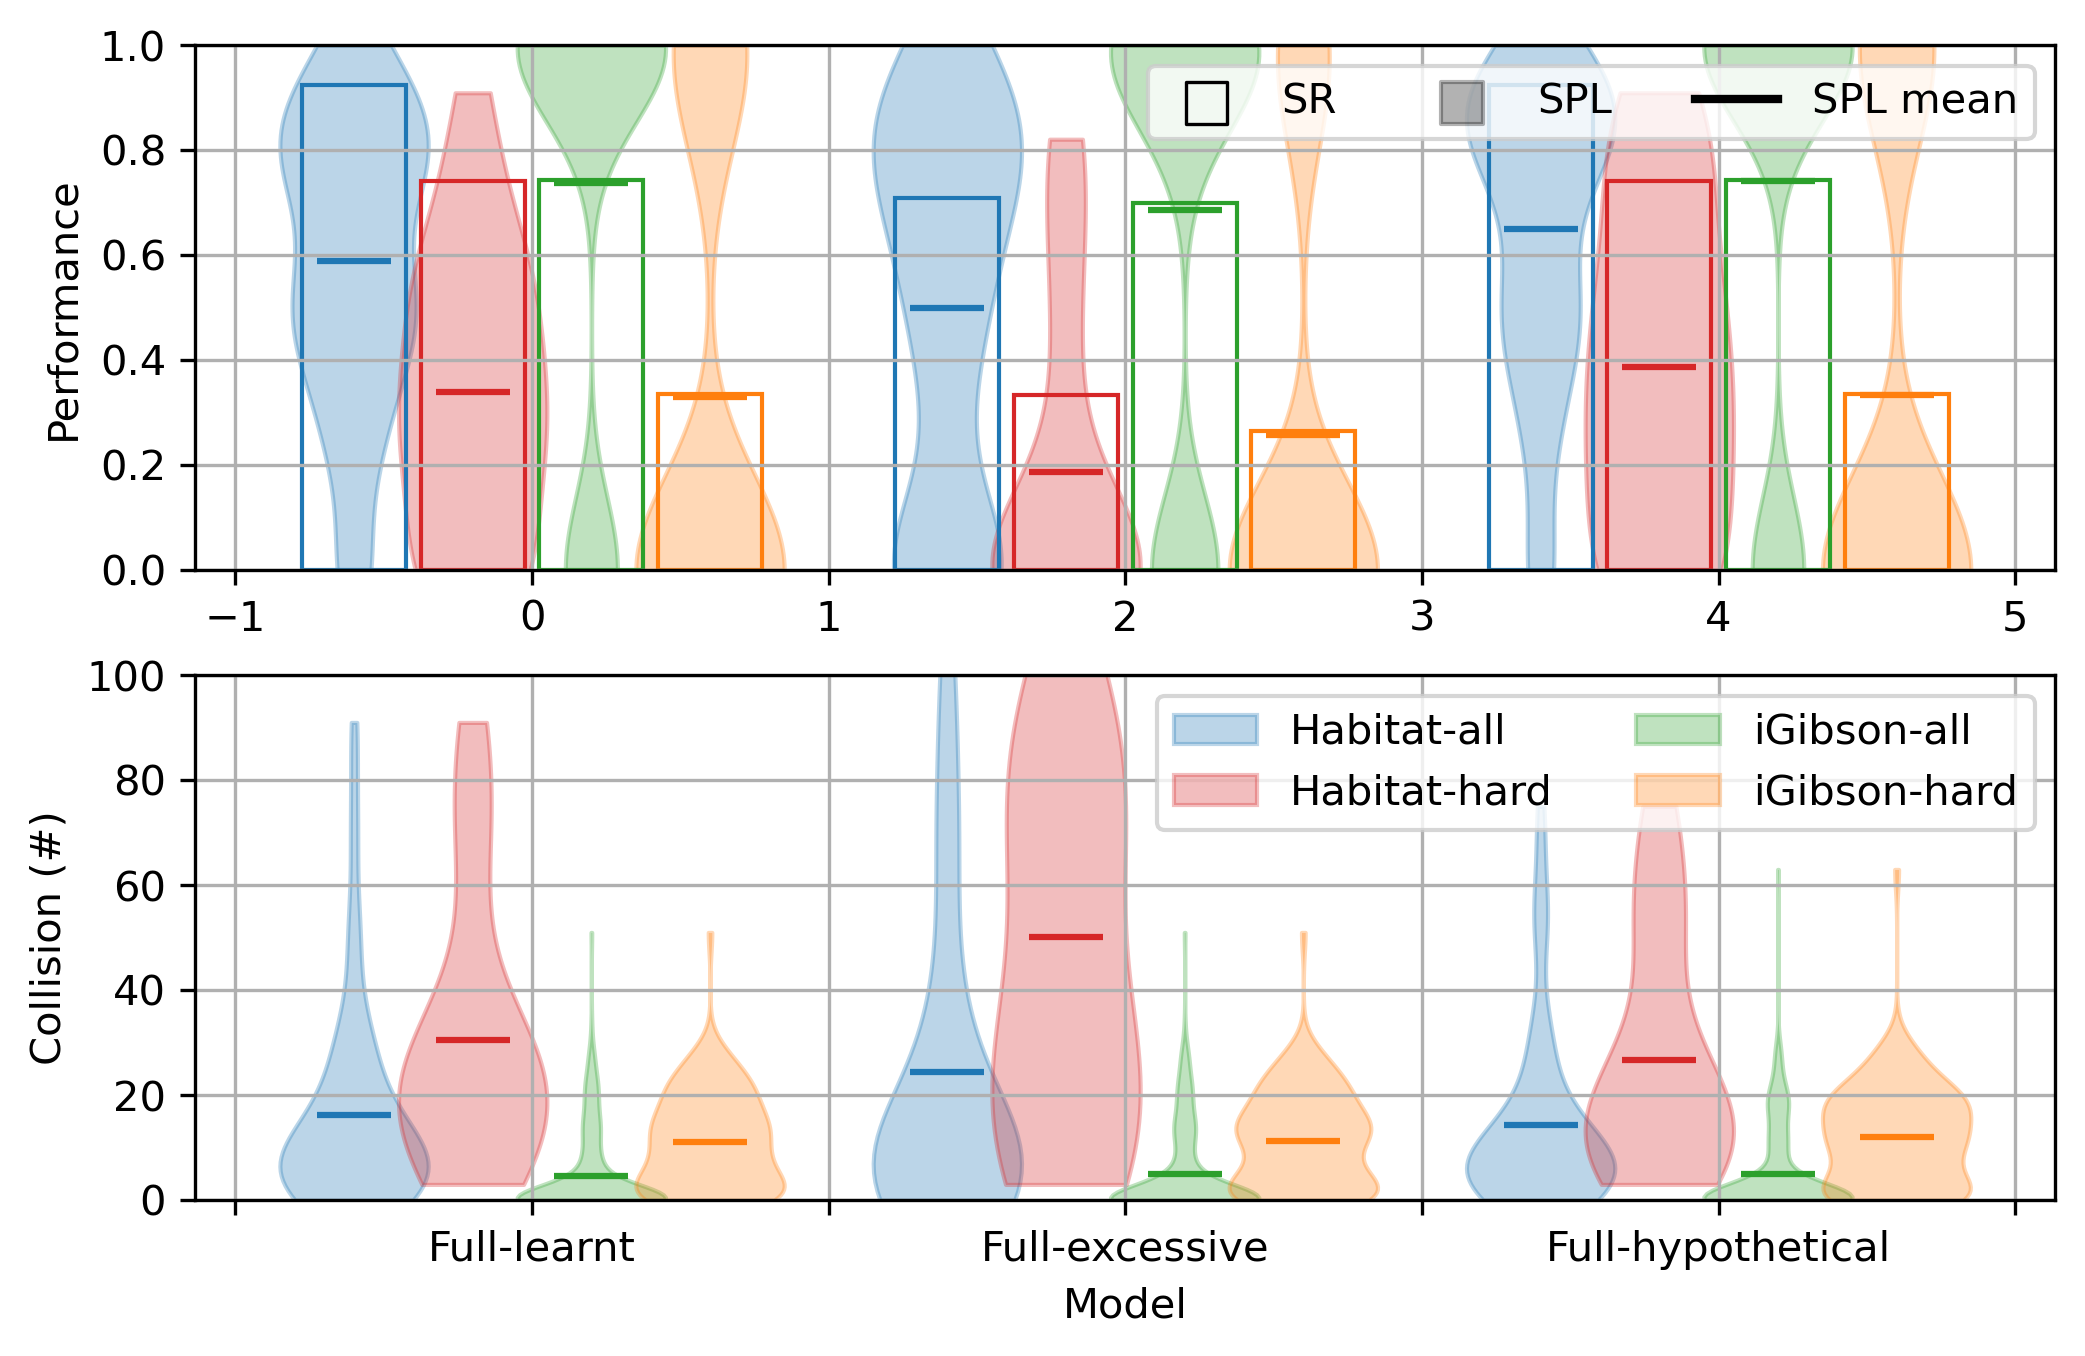

In [6]:
fig, axes = plt.subplots(2, 1, 
                         figsize=(8, 5), 
                         # sharex=True,
                         dpi=300)

model_names = ['Full-learnt', 'Full-pathological', 'Full-hypothetical']
colors = [['tab:blue', 'tab:red'], ['tab:green', 'tab:orange']]

n_model = len(model_names)
x0 = np.arange(n_model) * 2
xx = [[x0 - 0.6, x0 - 0.2], [x0 + 0.2, x0 + 0.6]]

for env, xe, ce in zip(env_names, 
                       xx,
                       colors):
    spl, sr, spl_hard, sr_hard = [], [], [], []
    for model in model_names:
        model_spl = df[env]['spl'].loc[slice(None), model]
        model_sr = model_spl[model_spl > 0].count() / model_spl.count()

        is_hard = df[env]['spl'].loc[slice(None), 'PI+escape'] == 0
        hard_spl = model_spl[is_hard]
        hard_sr = hard_spl[hard_spl > 0].count() / hard_spl.count()
        
        spl.append(model_spl)
        sr.append(model_sr)
        spl_hard.append(hard_spl)
        sr_hard.append(hard_sr)

    for c, x, y in zip(ce, xe, [spl, spl_hard]):
        vp = axes[0].violinplot(y,
                             positions=x,
                             showextrema=False, 
                             showmeans=True)
        for part in vp['bodies']:
            part.set_facecolor(c)
            part.set_edgecolor(c)
        vp['cmeans'].set_edgecolor(c)
    for c, x, y in zip(ce, xe, [sr, sr_hard]):
        axes[0].bar(x, y,
                 width=0.35, 
                 fill=False, 
                 edgecolor=c
                )


axes[0].set_ylabel('Performance')
axes[0].set_ylim(0, 1)

axes[0].scatter([], [], label='SR', facecolor='none', linewidth=0.8, edgecolor='k', marker='s', s=100)
axes[0].scatter([], [], label='SPL', color='k', alpha=0.3, marker='s', s=100)
axes[0].plot([], [], label='SPL mean', color='k', lw=2)
    


###################################################################



for env, xe, ce in zip(env_names, 
                   xx,
                   colors):
    col, col_hard = [], []
    for model in model_names:
        model_col = df[env]['collision'].loc[slice(None), model]

        is_hard = df[env]['spl'].loc[slice(None), 'PI+escape'] == 0
        hard_col = model_col[is_hard]
        
        col.append(model_col)
        col_hard.append(hard_col)
        

    for c, x, y in zip(ce, xe, [col, col_hard]):
        vp = axes[1].violinplot(y,
                           positions=x,
                           showextrema=False, 
                           showmeans=True)
        for part in vp['bodies']:
            part.set_facecolor(c)
            part.set_edgecolor(c)
        vp['cmeans'].set_edgecolor(c)


axes[1].set_ylim(0, 100)

xticks = np.insert(model_names, np.arange(n_model + 1), '')
xticks[3] = 'Full-excessive'
axes[1].set_xticks(np.arange(xticks.size) - 1, xticks)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Collision (#)')

for ce, env in zip(colors, env_names):
    for c, epi in zip(ce, ['all', 'hard']):
        axes[1].fill_between([], [], [], [], color=c, alpha=0.3, label=f'{env}-{epi}')

for ax in axes:
    ax.grid()

axes[0].legend(ncol=3, loc=1)


axes[1].legend(ncol=2, loc=1)
    
# plt.savefig("memory-effect.pdf", format="pdf", bbox_inches="tight", dpi=300)

In [7]:
######### ieee smaller plot
import matplotlib as mpl
mpl.rcParams.update({
    # "font.family": "serif",
    # "font.serif": ["Times New Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

plt.rcParams['lines.markersize'] = 7

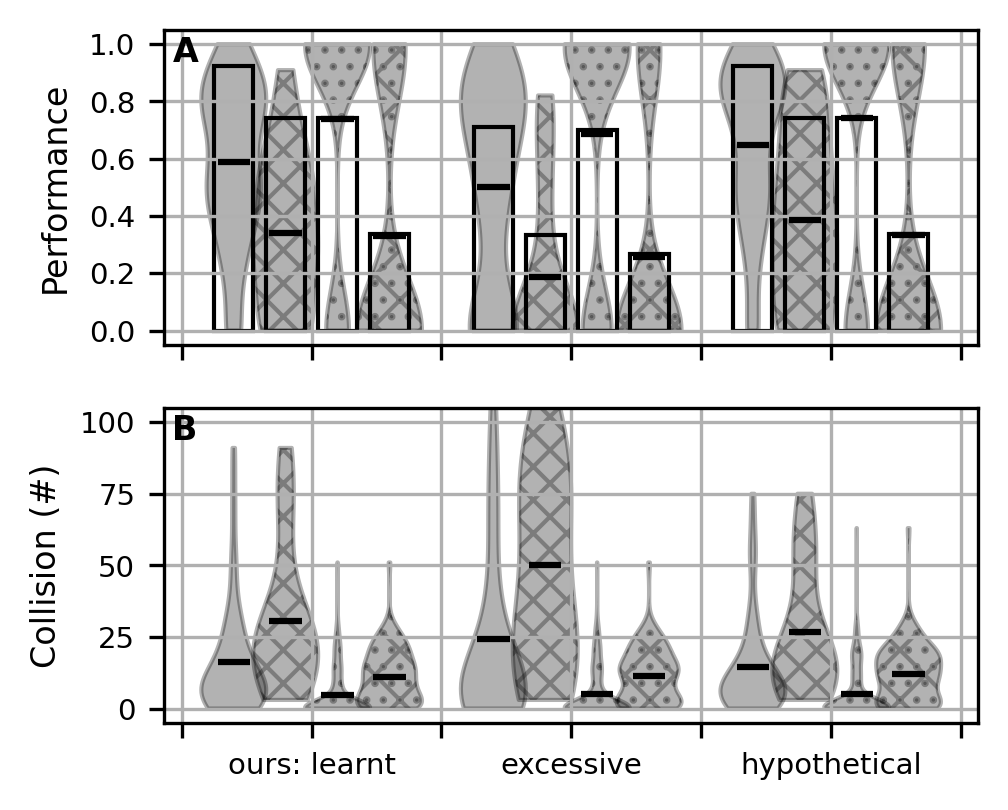

In [8]:
fig, axes = plt.subplots(2, 1, 
                         figsize=(3.5, 3), 
                         sharex=True,
                         dpi=300)

model_names = ['Full-learnt', 'Full-pathological', 'Full-hypothetical']
# colors = [['tab:blue', 'tab:red'], ['tab:green', 'tab:orange']]
colors = ['k', 'k'], ['k', 'k']
hatchs = [['', 'xxx'], ['...', 'xx...']]

n_model = len(model_names)
x0 = np.arange(n_model) * 2
xx = [[x0 - 0.6, x0 - 0.2], [x0 + 0.2, x0 + 0.6]]

for env, xe, ce, he in zip(env_names, 
                           xx,
                           colors,
                           hatchs
                          ):
    spl, sr, spl_hard, sr_hard = [], [], [], []
    for model in model_names:
        model_spl = df[env]['spl'].loc[slice(None), model]
        model_sr = model_spl[model_spl > 0].count() / model_spl.count()

        is_hard = df[env]['spl'].loc[slice(None), 'PI+escape'] == 0
        hard_spl = model_spl[is_hard]
        hard_sr = hard_spl[hard_spl > 0].count() / hard_spl.count()
        
        spl.append(model_spl)
        sr.append(model_sr)
        spl_hard.append(hard_spl)
        sr_hard.append(hard_sr)

    for c, h, x, y in zip(ce, he, xe, [spl, spl_hard]):
        vp = axes[0].violinplot(y,
                                positions=x,
                                showextrema=False, 
                                showmeans=True,
                               )
        for part in vp['bodies']:
            part.set_facecolor(c)
            part.set_edgecolor(c)
            part.set_hatch(h)
        vp['cmeans'].set_edgecolor(c)
    for c, x, y in zip(ce, xe, [sr, sr_hard]):
        axes[0].bar(x, y,
                 width=0.3, 
                 fill=False, 
                 edgecolor=c
                )


axes[0].set_ylabel('Performance')
axes[0].set_ylim(-.05, 1.05)
axes[0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

axes[0].scatter([], [], label='SR', facecolor='none', linewidth=0.8, edgecolor='k', marker='s', s=100)
axes[0].scatter([], [], label='SPL', color='k', alpha=0.3, marker='s', s=100)
axes[0].plot([], [], label='SPL mean', color='k', lw=2)
    


###################################################################



for env, xe, ce, he in zip(env_names, 
                       xx,
                       colors,
                       hatchs
                      ):
    col, col_hard = [], []
    for model in model_names:
        model_col = df[env]['collision'].loc[slice(None), model]

        is_hard = df[env]['spl'].loc[slice(None), 'PI+escape'] == 0
        hard_col = model_col[is_hard]
        
        col.append(model_col)
        col_hard.append(hard_col)
        

    for c, h, x, y in zip(ce, he, xe, [col, col_hard]):
        vp = axes[1].violinplot(y,
                           positions=x,
                           showextrema=False, 
                           showmeans=True)
        for part in vp['bodies']:
            part.set_facecolor(c)
            part.set_edgecolor(c)
            part.set_hatch(h)
        vp['cmeans'].set_edgecolor(c)


axes[1].set_ylim(-5, 105)

xticks = np.insert(['ours: learnt', 'excessive', 'hypothetical'], np.arange(n_model + 1), '')
# xticks[3] = 'Full-excessive'
axes[1].set_xticks(np.arange(xticks.size) - 1, xticks)
# axes[1].set_xlabel('Model')
axes[1].set_ylabel('Collision (#)')

for h, env in zip(['', '....'], env_names):
    axes[1].fill_between([], [], [], [], hatch=h, alpha=0.3, label=env, color='k')
for h, epi in zip(['', 'xxxx'], ['all', 'hard']):
    axes[1].fill_between([], [], [], [], hatch=h, alpha=0.3, label=epi, color='k')

for ax in axes:
    ax.grid()

# axes[0].legend(ncol=1, loc=0)

# axes[1].legend(ncol=4, loc=1)

for ax, label in zip(axes, 'AB'):
    
    ax.text(
        0.01, 0.98, label,
        transform=ax.transAxes,   # axes coordinates (0–1)
        fontsize=8,
        fontweight='bold',
        va='top',                 # anchor text to top
        ha='left'
    )
    
# plt.savefig("memory-effect.png", format="png", bbox_inches="tight", dpi=600)

['' 'A1: Odometry-only' '' 'A2: Odometry-collision' '']
['' 'ours: first attempt' '' 'ours: learnt' '']


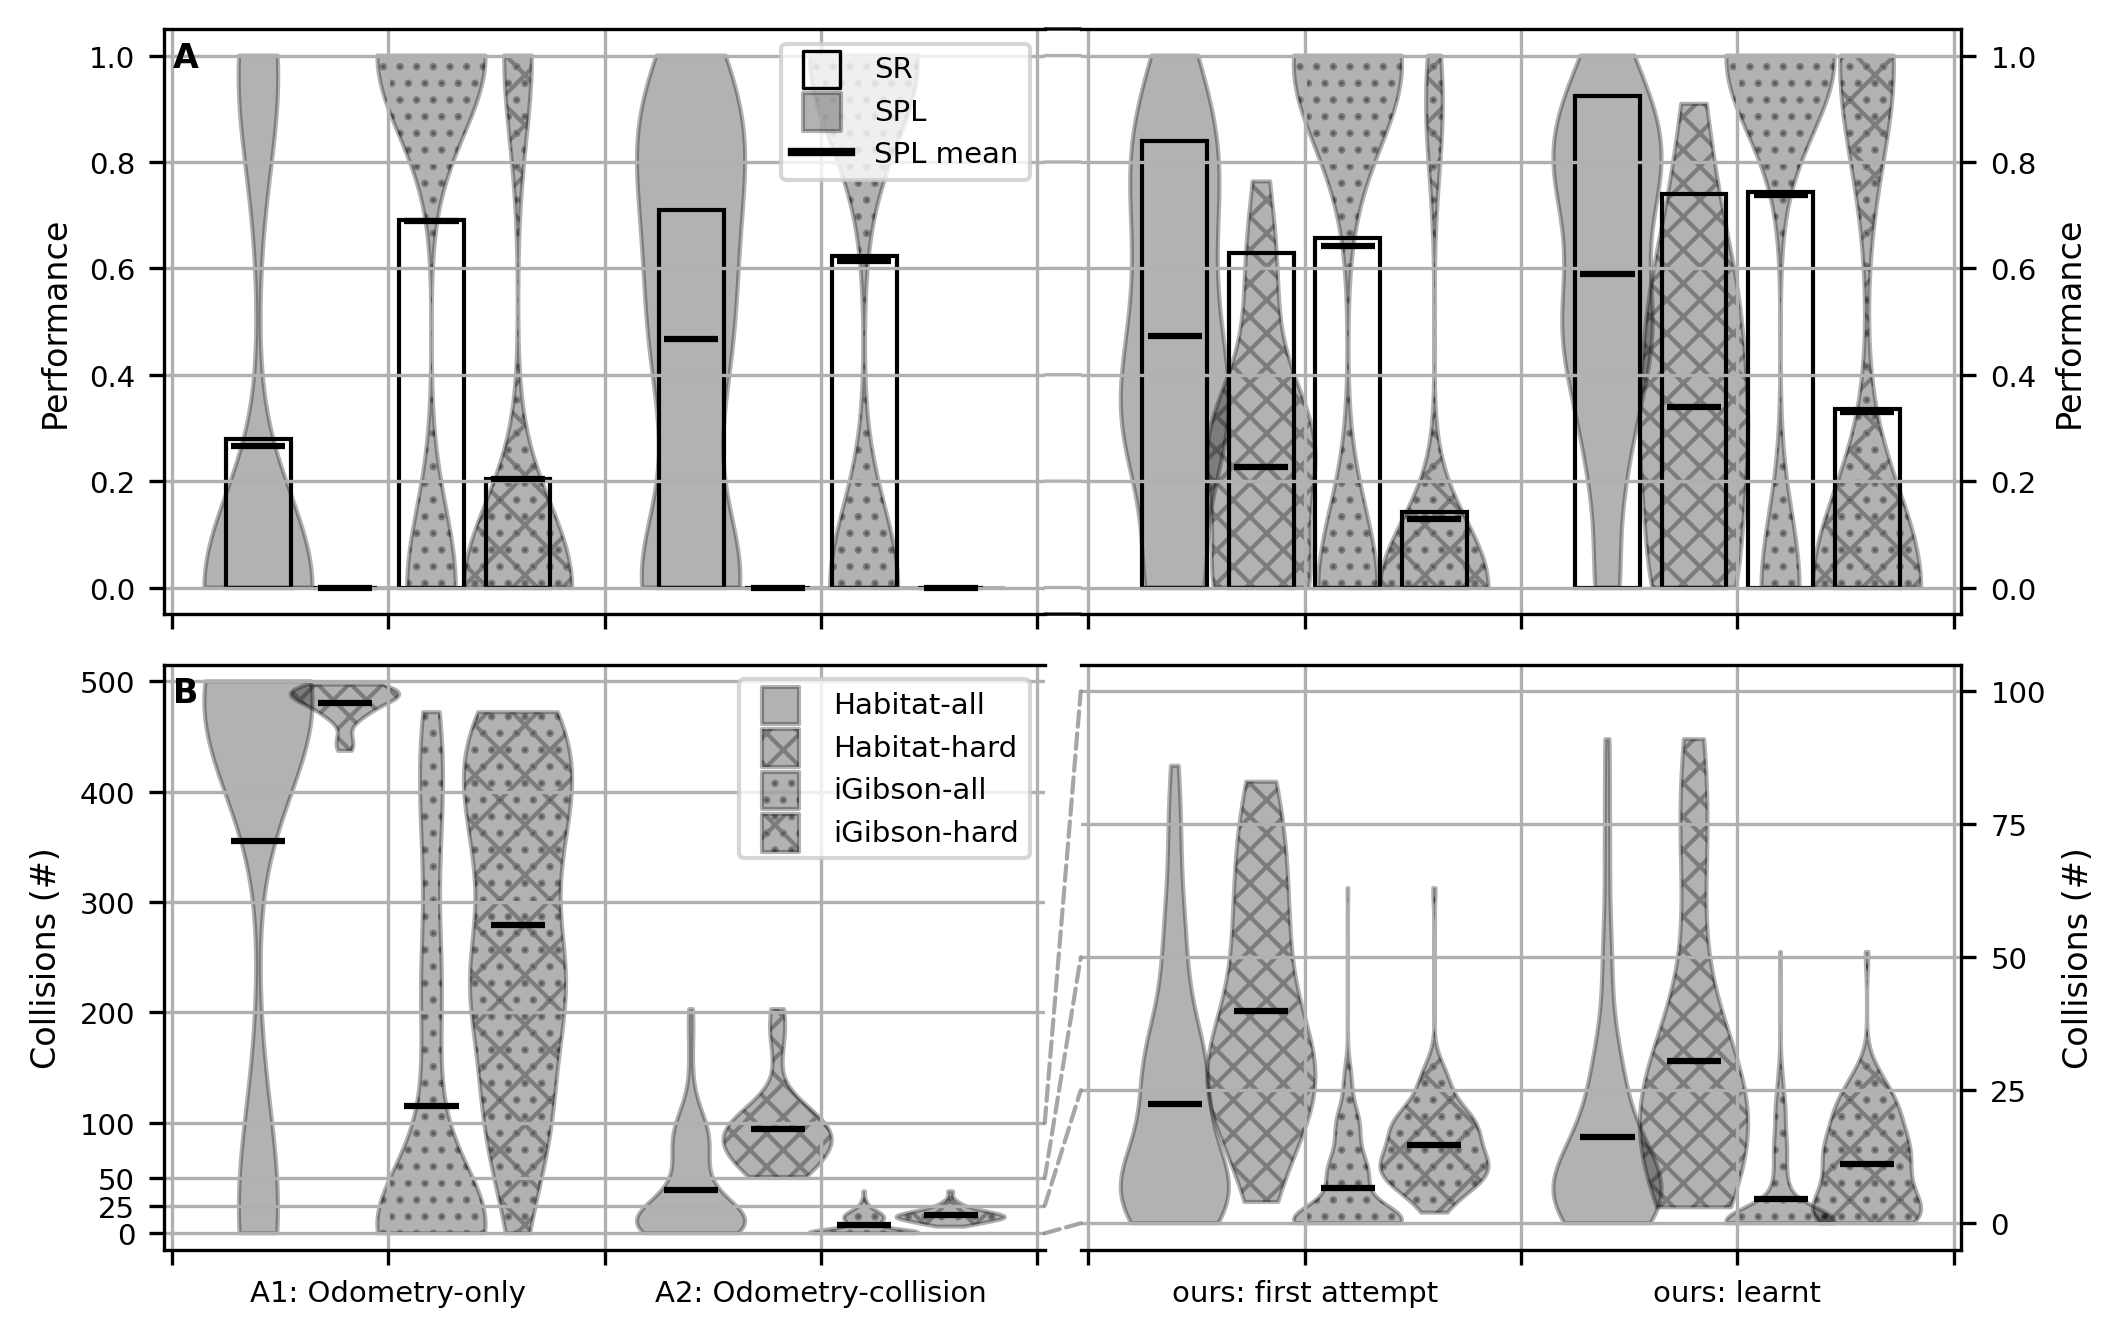

In [9]:
model_names = [['PI-only', 'PI+escape'], ['Full-first', 'Full-learnt']]
# colors = [['tab:blue', 'tab:red'], ['tab:green', 'tab:orange']]
colors = ['k', 'k'], ['k', 'k']

fig, axes = plt.subplots(2, 2, 
                         figsize=(7.125, 4.5), 
                         # gridspec_kw={'width_ratios': [1, 1]}, 
                         sharex='col',
                         layout='tight',
                         dpi=300)

for axcol, models, models_paper in zip(axes.T, model_names, np.reshape(model_names_paper, (2, 2))):
    n_model = len(models)
    x0 = np.arange(n_model) * 2
    xx = [[x0 - 0.6, x0 - 0.2], [x0 + 0.2, x0 + 0.6]]
    
    for env, xe, ce, he in zip(env_names, 
                               xx,
                               colors,
                               hatchs
                              ):
        
        spl, sr, spl_hard, sr_hard, col, col_hard = [], [], [], [], [], []
        for model in models:
            model_spl = df[env]['spl'].loc[slice(None), model]
            model_sr = model_spl[model_spl > 0].count() / model_spl.count()
            model_col = df[env]['collision'].loc[slice(None), model]
    
            # is_hard = df[env]['spl'].loc[slice(None), 'PI-only'] == 0
            is_hard = df[env]['spl'].loc[slice(None), 'PI+escape'] == 0
            hard_spl = model_spl[is_hard]
            hard_sr = hard_spl[hard_spl > 0].count() / hard_spl.count()
            hard_col = model_col[is_hard]
            
            spl.append(model_spl)
            sr.append(model_sr)
            spl_hard.append(hard_spl)
            sr_hard.append(hard_sr)            
            col.append(model_col)
            col_hard.append(hard_col)


        
        for c, h, x, y in zip(ce, he, xe, [col, col_hard]):
            vp = axcol[1].violinplot(y,
                               positions=x,
                               showextrema=False, 
                               showmeans=True)
            for part in vp['bodies']:
                part.set_facecolor(c)
                part.set_edgecolor(c)
                part.set_hatch(h)
            vp['cmeans'].set_edgecolor(c)

        for c, h, x, y in zip(ce, he, xe, [spl, spl_hard]):
            vp = axcol[0].violinplot(y,
                                 positions=x,
                                 showextrema=False, 
                                 showmeans=True)
            for part in vp['bodies']:
                part.set_facecolor(c)
                part.set_edgecolor(c)
                part.set_hatch(h)
            vp['cmeans'].set_edgecolor(c)
            
        for c, h, x, y in zip(ce, he, xe, [sr, sr_hard]):
            axcol[0].bar(x, y,
                     width=0.3, 
                     fill=False, 
                     edgecolor=c
                    )


axes[0,0].spines['right'].set_visible(False)
axes[0,1].spines['left'].set_visible(False)
axes[0,1].yaxis.set_label_position("right")
axes[0,1].yaxis.tick_right()

for ax in axes[0]:
    ax.set_ylim(-0.05, 1.05)
    ax.grid()
    ax.set_ylabel('Performance')

axes[1,0].spines['right'].set_visible(False)
axes[1,1].spines['left'].set_visible(False)
axes[1,1].yaxis.set_label_position("right")
axes[1,1].yaxis.tick_right()

for ax, ybot, ytop in zip(axes[1], [-15, -5], [515, 105]):
    ax.set_ylim(ybot, ytop)
    ax.grid()
    ax.set_ylabel('Collisions (#)')

axes[1,0].set_yticks(np.insert(np.arange(0, 501, 100), 1, [25, 50]))
axes[1,1].set_yticks(np.arange(0, 101, 25))

axes[0,0].scatter([], [], label='SR', facecolor='none', linewidth=0.8, edgecolor='k', marker='s', s=80)
axes[0,0].scatter([], [], label='SPL', color='k', alpha=0.3, marker='s', s=80)
axes[0,0].plot([], [], label='SPL mean', color='k', lw=2)

for he, env in zip(hatchs, env_names):
    for h, epi in zip(he, ['all', 'hard']):
        axes[1,0].scatter([], [], marker='s', s=80, color='k', hatch=h, alpha=0.3, label=f'{env}-{epi}')

for ax in axes.T[0]:
    ax.legend(ncol=1)#, loc='upper left', bbox_to_anchor=(1.2,1))



### connecting two subplots
from matplotlib.patches import ConnectionPatch

gl = axes[0,0].get_xgridlines()[0]
sp = axes[0,0].spines['bottom']

for con_val in [0, 0.2, 0.4, 0.6, 0.8, 1]:
    con = ConnectionPatch(xyA=(axes[0,0].get_xlim()[1], con_val), xyB=(axes[1,1].get_xlim()[0], con_val),
                         coordsA='data', coordsB='data',
                         axesA=axes[0,0], axesB=axes[0,1],
                         linestyle=gl.get_linestyle(), 
                          linewidth=gl.get_linewidth(), 
                          color=gl.get_color(), 
                          alpha=gl.get_alpha())
    
    # Add the connection to the figure
    fig.add_artist(con)

for con_val in [-0.05, 1.05]:
    con = ConnectionPatch(xyA=(axes[0,0].get_xlim()[1], con_val), xyB=(axes[1,1].get_xlim()[0], con_val),
                         coordsA='data', coordsB='data',
                         axesA=axes[0,0], axesB=axes[0,1],
                         linestyle='-', 
                          linewidth=sp.get_linewidth(), 
                          color='k', 
                          alpha=1)
    
    # Add the connection to the figure
    fig.add_artist(con)


for con_val in [0, 25, 50, 100]:
    con = ConnectionPatch(xyA=(axes[1,0].get_xlim()[1], con_val), xyB=(axes[1,1].get_xlim()[0], con_val),
                         coordsA='data', coordsB='data',
                         axesA=axes[1,0], axesB=axes[1,1],
                         linestyle='--', linewidth=1, color='gray', alpha=0.7)
    
    # Add the connection to the figure
    fig.add_artist(con)


for ax, label in zip([axes[0,0],axes[1,0]], 'AB'):
    
    ax.text(
        0.01, 0.98, label,
        transform=ax.transAxes,   # axes coordinates (0–1)
        fontsize=8,
        fontweight='bold',
        va='top',                 # anchor text to top
        ha='left'
    )

model_names_paper = ['A1: Odometry-only', 'A2: Odometry-collision', 'ours: first attempt', 'ours: learnt']

for axcol, models_paper in zip(axes.T, np.reshape(model_names_paper, (2, 2))):
    xticks = np.insert(models_paper, np.arange(3), '')
    axcol[1].set_xticks(np.arange(xticks.size) - 1, xticks)
    print(xticks)


    
# plt.savefig("model-performance-collision.png", format="png", bbox_inches="tight", dpi=600)

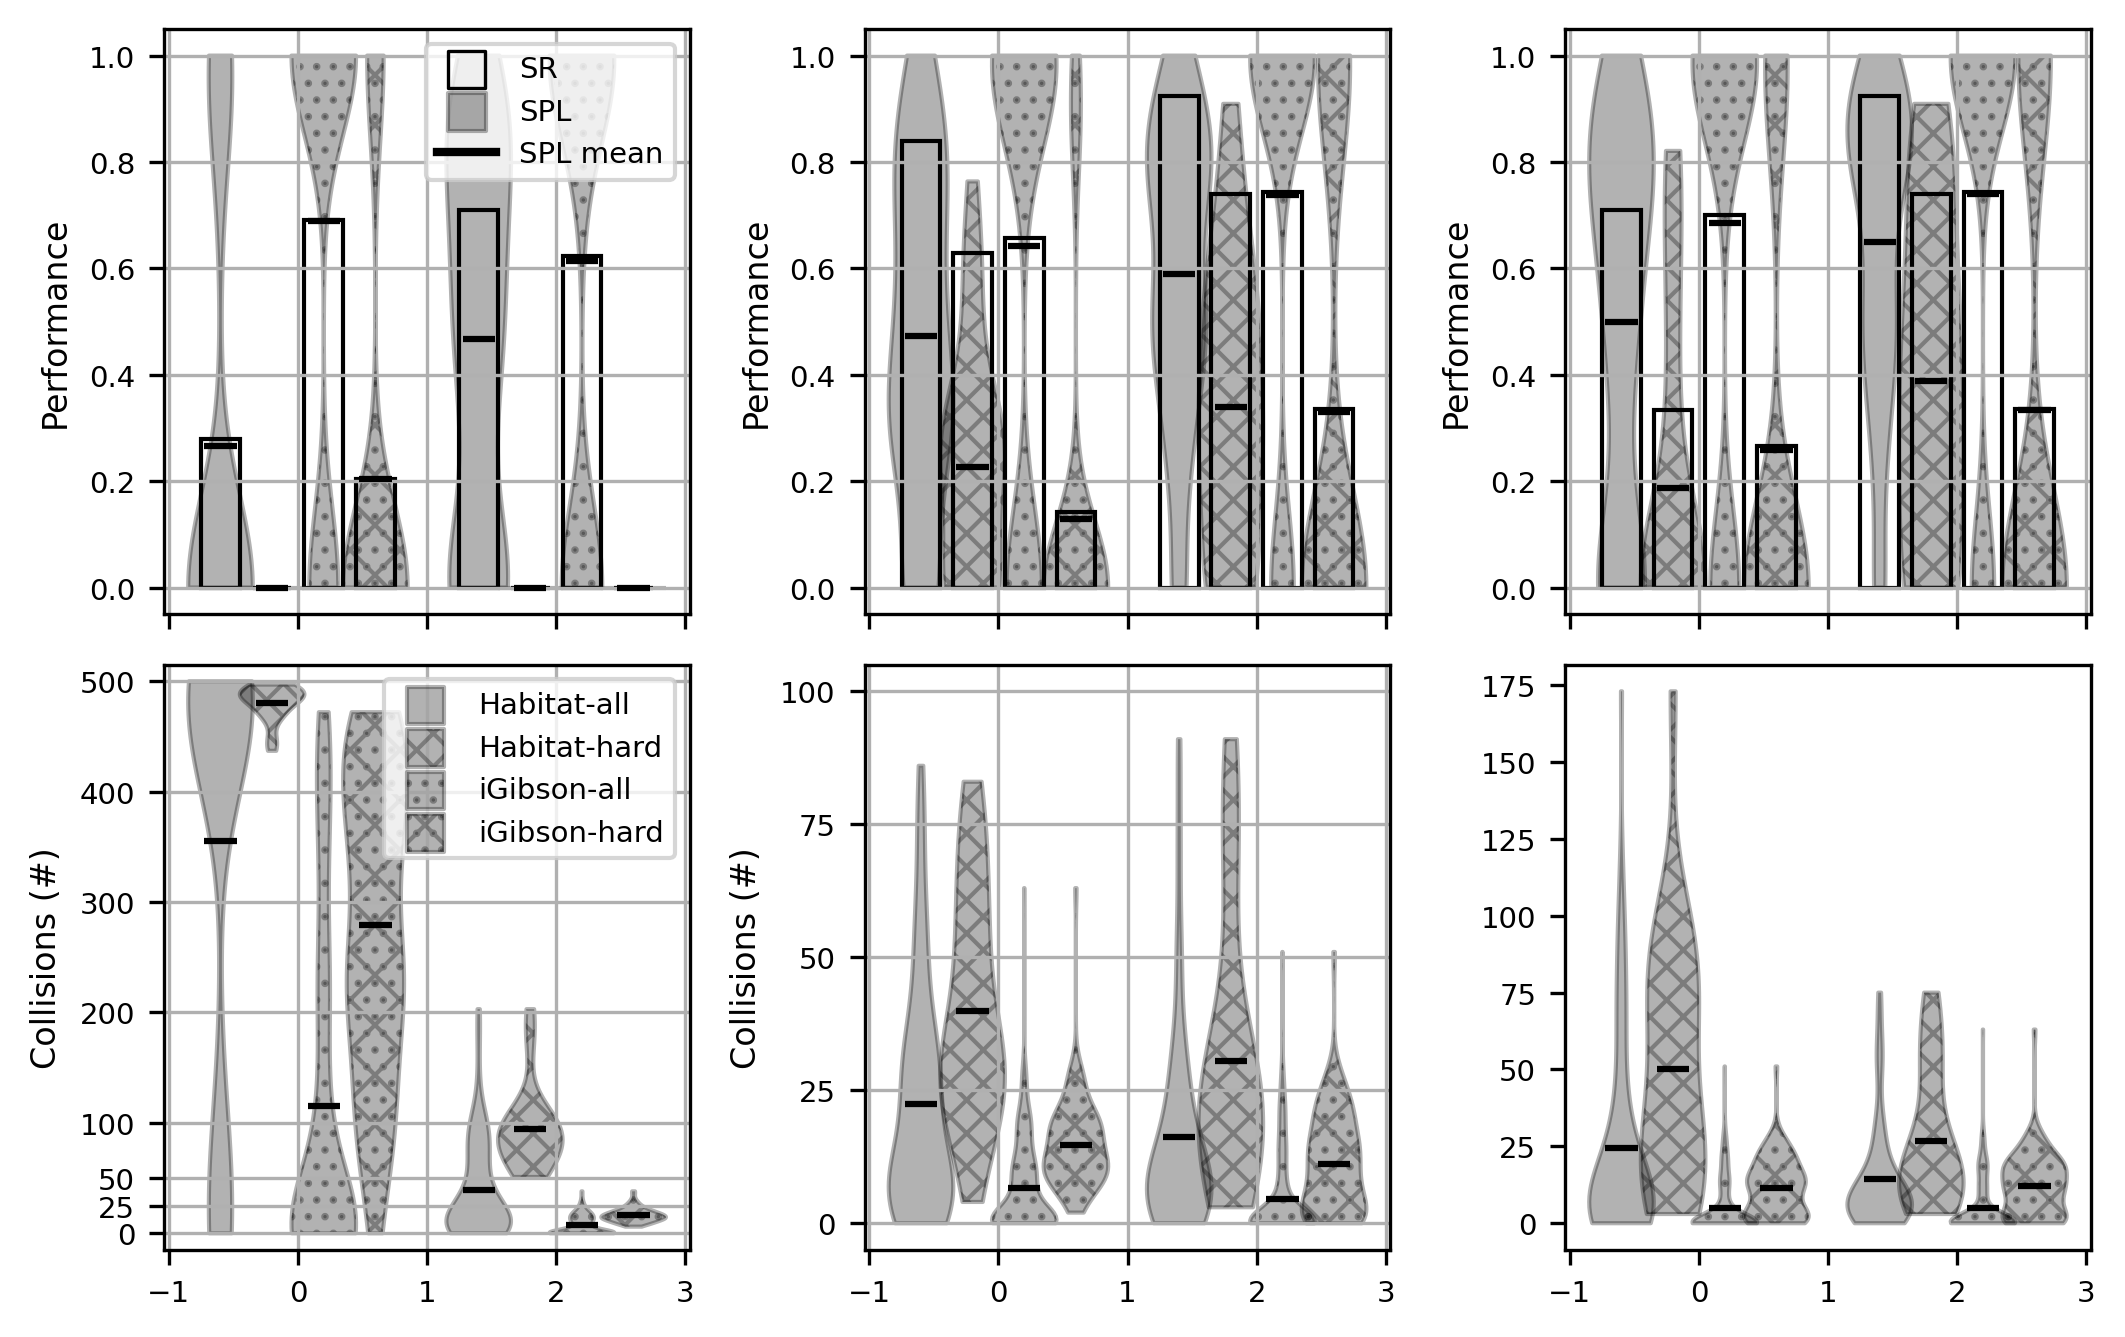

In [10]:
model_names = [['PI-only', 'PI+escape'], ['Full-first', 'Full-learnt'], ['Full-pathological', 'Full-hypothetical']]
model_names_paper = ['A1: Odometry-only', 'A2: Odometry-collision', 'ours: first attempt', 'ours: learnt', 'excessive', 'hypothetical']
colors = ['k', 'k'], ['k', 'k'], ['k', 'k']

fig, axes = plt.subplots(2, 3, 
                         figsize=(7.125, 4.5), 
                         # gridspec_kw={'width_ratios': [1, 1]}, 
                         sharex='col',
                         layout='tight',
                         dpi=300)

for axcol, models, models_paper in zip(axes.T, model_names, np.reshape(model_names_paper, (3, 2))):
    x0 = np.arange(n_model) * 2
    xx = [[x0 - 0.6, x0 - 0.2], [x0 + 0.2, x0 + 0.6]]
    
    for env, xe, ce, he in zip(env_names, 
                               xx,
                               colors,
                               hatchs
                              ):
        
        spl, sr, spl_hard, sr_hard, col, col_hard = [], [], [], [], [], []
        for model in models:
            model_spl = df[env]['spl'].loc[slice(None), model]
            model_sr = model_spl[model_spl > 0].count() / model_spl.count()
            model_col = df[env]['collision'].loc[slice(None), model]
    
            # is_hard = df[env]['spl'].loc[slice(None), 'PI-only'] == 0
            is_hard = df[env]['spl'].loc[slice(None), 'PI+escape'] == 0
            hard_spl = model_spl[is_hard]
            hard_sr = hard_spl[hard_spl > 0].count() / hard_spl.count()
            hard_col = model_col[is_hard]
            
            spl.append(model_spl)
            sr.append(model_sr)
            spl_hard.append(hard_spl)
            sr_hard.append(hard_sr)            
            col.append(model_col)
            col_hard.append(hard_col)


        
        for c, h, x, y in zip(ce, he, xe, [col, col_hard]):
            vp = axcol[1].violinplot(y,
                               positions=x,
                               showextrema=False, 
                               showmeans=True)
            for part in vp['bodies']:
                part.set_facecolor(c)
                part.set_edgecolor(c)
                part.set_hatch(h)
            vp['cmeans'].set_edgecolor(c)

        for c, h, x, y in zip(ce, he, xe, [spl, spl_hard]):
            vp = axcol[0].violinplot(y,
                                 positions=x,
                                 showextrema=False, 
                                 showmeans=True)
            for part in vp['bodies']:
                part.set_facecolor(c)
                part.set_edgecolor(c)
                part.set_hatch(h)
            vp['cmeans'].set_edgecolor(c)
            
        for c, h, x, y in zip(ce, he, xe, [sr, sr_hard]):
            axcol[0].bar(x, y,
                     width=0.3, 
                     fill=False, 
                     edgecolor=c
                    )


# axes[0,0].spines['right'].set_visible(False)
# axes[0,1].spines['left'].set_visible(False)
# axes[0,1].yaxis.set_label_position("right")
# axes[0,1].yaxis.tick_right()

for ax in axes[0]:
    ax.set_ylim(-0.05, 1.05)
    ax.grid()
    ax.set_ylabel('Performance')

# axes[1,0].spines['right'].set_visible(False)
# axes[1,1].spines['left'].set_visible(False)
# axes[1,1].yaxis.set_label_position("right")
# axes[1,1].yaxis.tick_right()

for ax, ybot, ytop in zip(axes[1], [-15, -5], [515, 105]):
    ax.set_ylim(ybot, ytop)
    ax.grid()
    ax.set_ylabel('Collisions (#)')

axes[1,0].set_yticks(np.insert(np.arange(0, 501, 100), 1, [25, 50]))
axes[1,1].set_yticks(np.arange(0, 101, 25))

axes[0,0].scatter([], [], label='SR', facecolor='none', linewidth=0.8, edgecolor='k', marker='s', s=80)
axes[0,0].scatter([], [], label='SPL', color='k', alpha=0.3, marker='s', s=80)
axes[0,0].plot([], [], label='SPL mean', color='k', lw=2)

for he, env in zip(hatchs, env_names):
    for h, epi in zip(he, ['all', 'hard']):
        axes[1,0].scatter([], [], marker='s', s=80, color='k', hatch=h, alpha=0.3, label=f'{env}-{epi}')

for ax in axes.T[0]:
    ax.legend(ncol=1)#, loc='upper left', bbox_to_anchor=(1.2,1))



### connecting two subplots
# from matplotlib.patches import ConnectionPatch

# gl = axes[0,0].get_xgridlines()[0]
# sp = axes[0,0].spines['bottom']

# for con_val in [0, 0.2, 0.4, 0.6, 0.8, 1]:
#     con = ConnectionPatch(xyA=(axes[0,0].get_xlim()[1], con_val), xyB=(axes[1,1].get_xlim()[0], con_val),
#                          coordsA='data', coordsB='data',
#                          axesA=axes[0,0], axesB=axes[0,1],
#                          linestyle=gl.get_linestyle(), 
#                           linewidth=gl.get_linewidth(), 
#                           color=gl.get_color(), 
#                           alpha=gl.get_alpha())
    
#     # Add the connection to the figure
#     fig.add_artist(con)

# for con_val in [-0.05, 1.05]:
#     con = ConnectionPatch(xyA=(axes[0,0].get_xlim()[1], con_val), xyB=(axes[1,1].get_xlim()[0], con_val),
#                          coordsA='data', coordsB='data',
#                          axesA=axes[0,0], axesB=axes[0,1],
#                          linestyle='-', 
#                           linewidth=sp.get_linewidth(), 
#                           color='k', 
#                           alpha=1)
    
#     # Add the connection to the figure
#     fig.add_artist(con)


# for con_val in [0, 25, 50, 100]:
#     con = ConnectionPatch(xyA=(axes[1,0].get_xlim()[1], con_val), xyB=(axes[1,1].get_xlim()[0], con_val),
#                          coordsA='data', coordsB='data',
#                          axesA=axes[1,0], axesB=axes[1,1],
#                          linestyle='--', linewidth=1, color='gray', alpha=0.7)
    
#     # Add the connection to the figure
#     fig.add_artist(con)


# for ax, label in zip([axes[0,0],axes[1,0]], 'AB'):
    
#     ax.text(
#         0.01, 0.98, label,
#         transform=ax.transAxes,   # axes coordinates (0–1)
#         fontsize=8,
#         fontweight='bold',
#         va='top',                 # anchor text to top
#         ha='left'
#     )

# model_names_paper = ['A1: Odometry-only', 'A2: Odometry-collision', 'ours: first attempt', 'ours: learnt']

# for axcol, models_paper in zip(axes.T, np.reshape(model_names_paper, (2, 2))):
#     xticks = np.insert(models_paper, np.arange(3), '')
#     axcol[1].set_xticks(np.arange(xticks.size) - 1, xticks)
#     print(xticks)


    
# plt.savefig("model-performance-collision2.png", format="png", bbox_inches="tight", dpi=600)

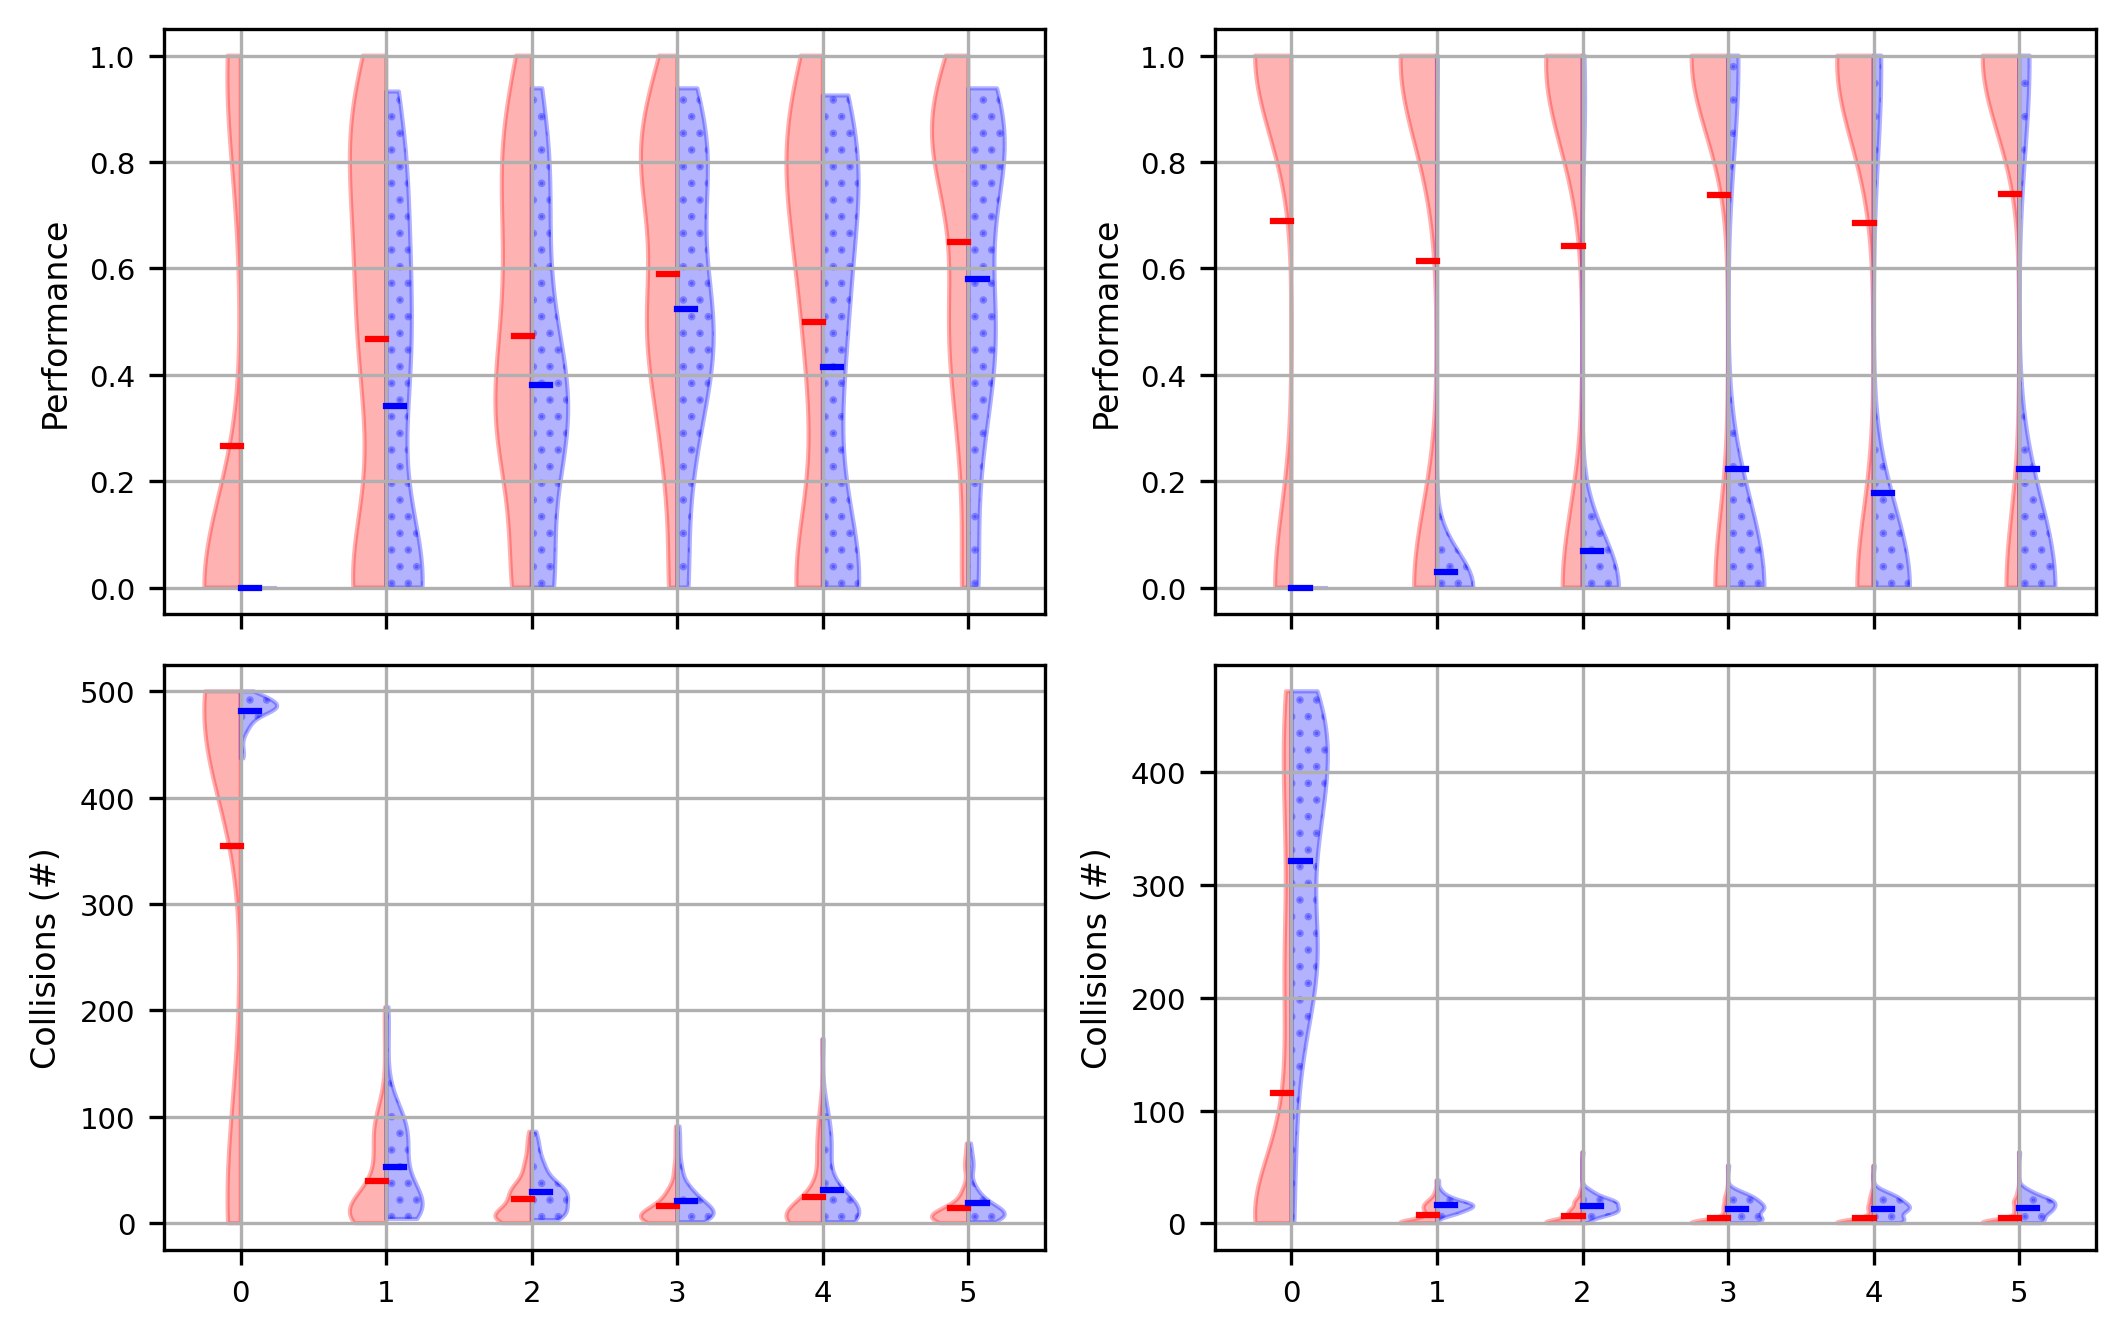

In [11]:
model_names = [['PI-only', 'PI+escape'], ['Full-first', 'Full-learnt'], ['Full-pathological', 'Full-hypothetical']]
model_names_paper = ['A1: Odometry-only', 'A2: Odometry-collision', 'ours: first attempt', 'ours: learnt', 'excessive', 'hypothetical']

fig, axes = plt.subplots(2, 2, 
                         figsize=(7.125, 4.5), 
                         # gridspec_kw={'width_ratios': [1, 1]}, 
                         sharex='col',
                         layout='tight',
                         dpi=300)

data = {
    (0, 0): {'m1': [12], 'm2_6': [10, 14, 11, 15, 13]}, 
    (0, 1): {'m1': [11], 'm2_6': [9, 13, 10, 14, 12]},  
    (1, 0): {'m1': [800], 'm2_6': [5, 8, 4, 7, 6]},     
    (1, 1): {'m1': [950], 'm2_6': [4, 7, 3, 6, 5]}      
}

data_hard = {
    (0, 0): {'m1': [12], 'm2_6': [10, 14, 11, 15, 13]}, 
    (0, 1): {'m1': [11], 'm2_6': [9, 13, 10, 14, 12]},  
    (1, 0): {'m1': [800], 'm2_6': [5, 8, 4, 7, 6]},     
    (1, 1): {'m1': [950], 'm2_6': [4, 7, 3, 6, 5]}      
}

for axcol, env, coli in zip(axes.T, env_names, [0, 1]):
    spl, sr, spl_hard, sr_hard, col, col_hard = [], [], [], [], [], []    
    for model in np.ravel(model_names):
        model_spl = df[env]['spl'].loc[slice(None), model]
        model_sr = model_spl[model_spl > 0].count() / model_spl.count()
        model_col = df[env]['collision'].loc[slice(None), model]

        is_hard = df[env]['spl'].loc[slice(None), 'PI-only'] == 0
        # is_hard = df[env]['spl'].loc[slice(None), 'PI+escape'] == 0
        hard_spl = model_spl[is_hard]
        hard_sr = hard_spl[hard_spl > 0].count() / hard_spl.count()
        hard_col = model_col[is_hard]
        
        spl.append(model_spl)
        sr.append(model_sr)
        spl_hard.append(hard_spl)
        sr_hard.append(hard_sr)            
        col.append(model_col)
        col_hard.append(hard_col)

    data[(0, coli)]['m1'] = spl[0]
    data[(0, coli)]['m2_6'] = spl[1:]
    data[(1, coli)]['m1'] = col[0]
    data[(1, coli)]['m2_6'] = col[1:]
    
    data_hard[(0, coli)]['m1'] = spl_hard[0]
    data_hard[(0, coli)]['m2_6'] = spl_hard[1:]
    data_hard[(1, coli)]['m1'] = col_hard[0]
    data_hard[(1, coli)]['m2_6'] = col_hard[1:]
    
    x = np.arange(0, 6, 1)

    for ax, ydata in zip(axcol, [[spl, spl_hard], [col, col_hard]]):
        for c, h, y, sid in zip('rb', ['', '...'], ydata, ['low', 'high']):
            vp = ax.violinplot(y,
                               positions=x,                            
                               side=sid,
                               showextrema=False, 
                               showmeans=True)
            for part in vp['bodies']:
                part.set_facecolor(c)
                part.set_edgecolor(c)
                part.set_hatch(h)
            vp['cmeans'].set_edgecolor(c)
        
    # for c, h, y in zip(ce, he, [sr, sr_hard]):
    #     axcol[0].bar(x, y,
    #              width=0.3, 
    #              fill=False, 
    #              edgecolor=c
    #             )



for ax in axes[0]:
    ax.set_ylim(-0.05, 1.05)
    ax.grid()
    ax.set_ylabel('Performance')


for ax, ybot, ytop in zip(axes[1], [-15, -5], [515, 500]):
    # ax.set_ylim(ybot, ytop)
    ax.grid()
    ax.set_ylabel('Collisions (#)')

# axes[1,0].set_yticks(np.insert(np.arange(0, 501, 100), 1, [25, 50]))
# axes[1,1].set_yticks(np.arange(0, 101, 25))

axes[0,0].scatter([], [], label='SR', facecolor='none', linewidth=0.8, edgecolor='k', marker='s', s=80)
axes[0,0].scatter([], [], label='SPL', color='k', alpha=0.3, marker='s', s=80)
axes[0,0].plot([], [], label='SPL mean', color='k', lw=2)

for he, env in zip(hatchs, env_names):
    for h, epi in zip(he, ['all', 'hard']):
        axes[1,0].scatter([], [], marker='s', s=80, color='k', hatch=h, alpha=0.3, label=f'{env}-{epi}')



    
# plt.savefig("model-performance-collision2.png", format="png", bbox_inches="tight", dpi=600)

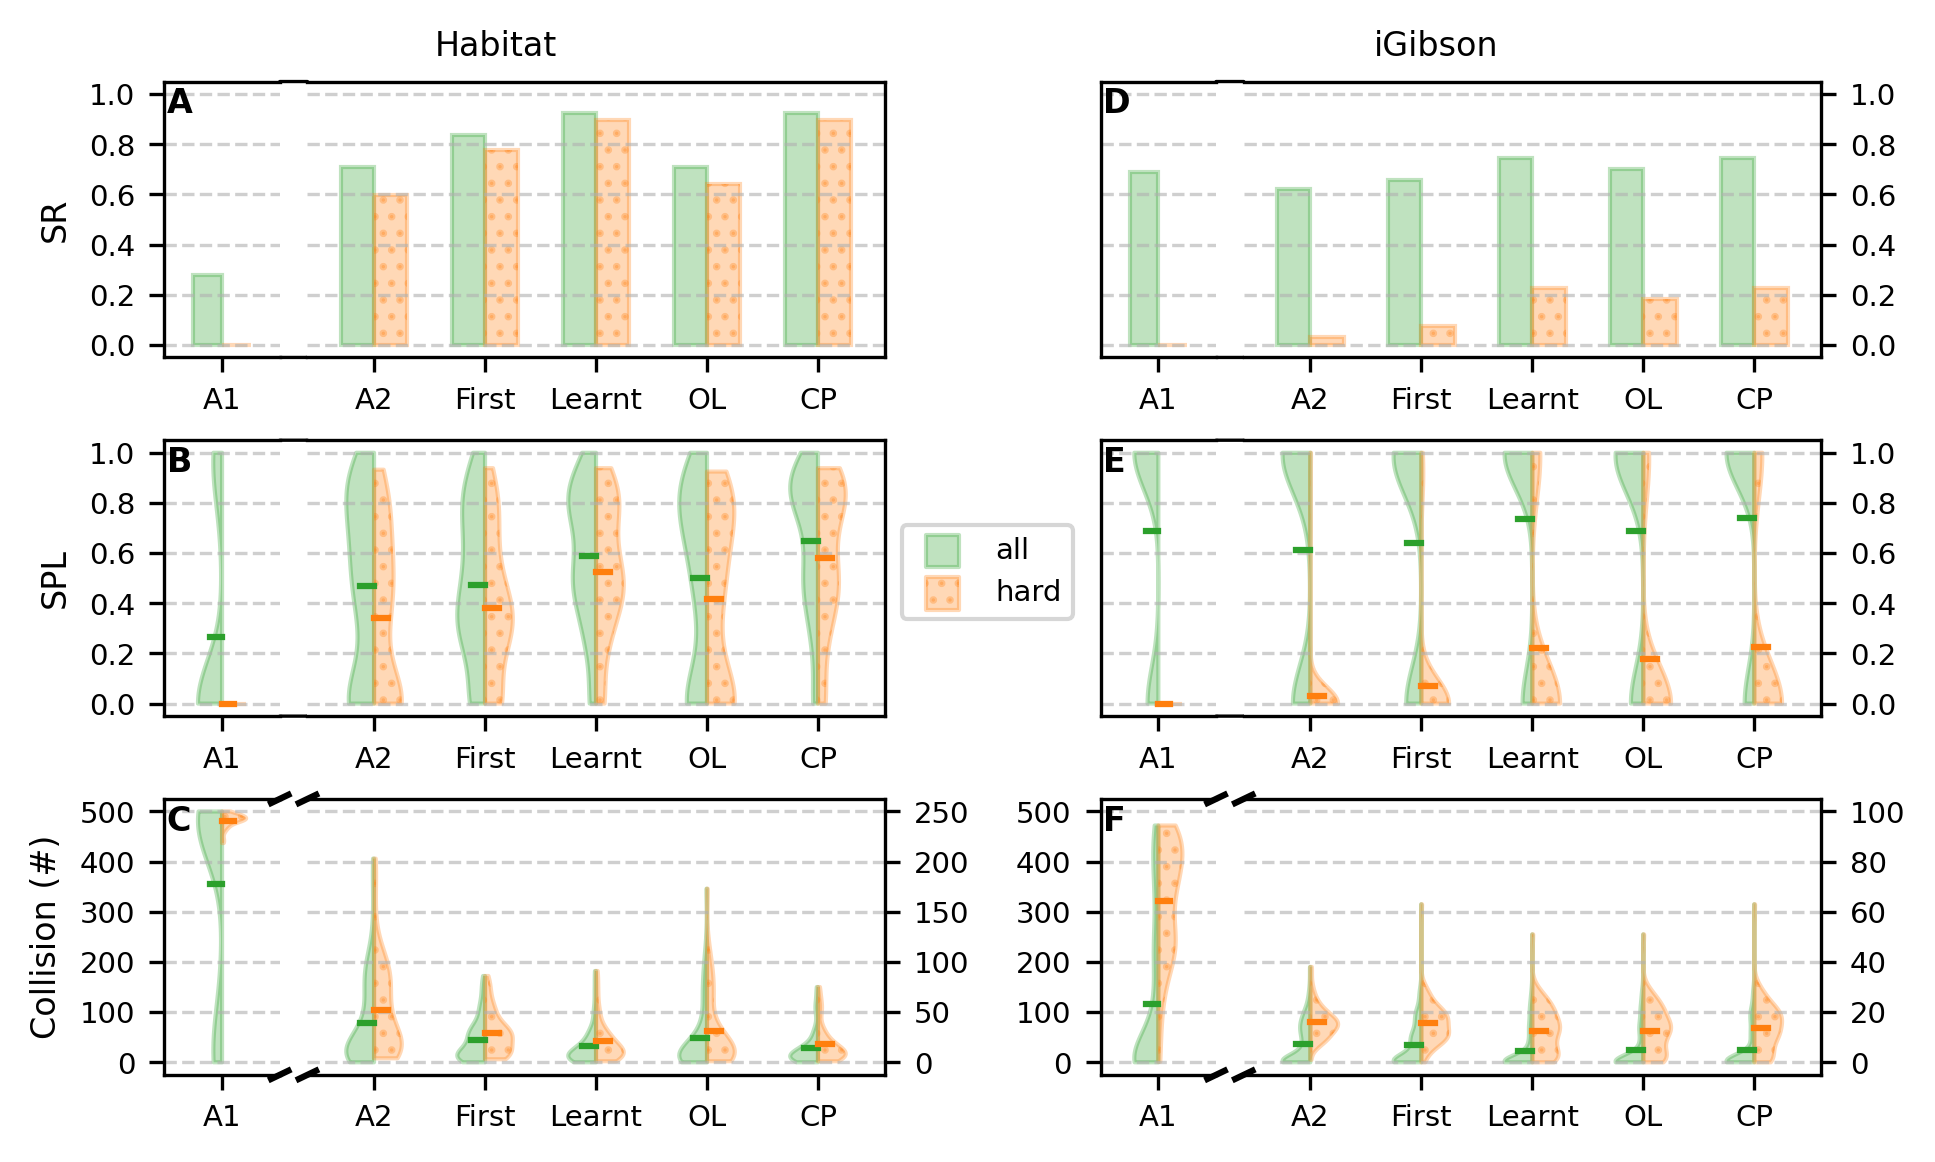

In [75]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import ConnectionPatch

# --- 1. Mock Data Setup ---
models = 'A1', 'A2', 'First', 'Learnt', 'OL', 'CP'
x_m1 = [0]
x_m2_6 = [1, 2, 3, 4, 5]
fullhardcolor = 'tab:green', 'tab:orange'

# --- 2. Figure Setup ---
fig = plt.figure(figsize=(7.125, 4.3), dpi=300)
outer_gs = gridspec.GridSpec(3, 2, wspace=0.3, hspace=0.3, height_ratios=[1, 1, 1])

# --- 3. Plotting Loop ---
for r in range(3):
    for c in range(2):
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            1, 2, subplot_spec=outer_gs[r, c], width_ratios=[1, 5], wspace=0.08
        )
        
        ax_left = fig.add_subplot(inner_gs[0])
        ax_right = fig.add_subplot(inner_gs[1])

        for color, h, sid, d in zip(fullhardcolor, ['', '...'], ['low', 'high'], [data, data_hard]):
            if r == 0:
                d_m1, d_m2_6 = d[(r, c)]['m1'], d[(r, c)]['m2_6']
                xjitter = {'low': -0.15, 'high': 0.15}[sid]
                y_m1 = np.count_nonzero(d_m1 > 0) / len(d_m1)
                ax_left.bar(np.array(x_m1) + xjitter, y_m1,
                            width=0.3, 
                            color=color,
                            edgecolor=color,
                            alpha=0.3,
                             hatch=h
                           )
                y_m2_6 = np.divide(np.count_nonzero(np.array(d_m2_6) > 0, axis=1), np.shape(d_m2_6)[1])
                ax_right.bar(np.array(x_m2_6) + xjitter, y_m2_6,
                            width=0.3, 
                            color=color,
                            edgecolor=color,
                            alpha=0.3,
                             hatch=h
                           )
            else:                
                d_m1, d_m2_6 = d[(r-1, c)]['m1'], d[(r-1, c)]['m2_6']
                vp = ax_left.violinplot(d_m1,
                                   positions=x_m1,     
                                   side=sid,
                                   showextrema=False, 
                                   showmeans=True)
                vp['cmeans'].set_edgecolor(color)
                for part in vp['bodies']:
                    part.set_facecolor(color)
                    part.set_edgecolor(color)
                    part.set_hatch(h)
                vp = ax_right.violinplot(d_m2_6,
                                   positions=x_m2_6,     
                                   side=sid,
                                   showextrema=False, 
                                   showmeans=True)
                vp['cmeans'].set_edgecolor(color)
                for part in vp['bodies']:
                    part.set_facecolor(color)
                    part.set_edgecolor(color)
                    part.set_hatch(h)
        
        ax_left.set_xlim(-0.6, 0.6)
        ax_right.set_xlim(0.4, 5.6)

        ax_left.set_xticks(x_m1)
        ax_right.set_xticks(x_m2_6)
        ax_left.set_xticklabels([models[0]])
        ax_right.set_xticklabels(models[1:])

        
        for ax in (ax_left, ax_right):
            ax.grid(True, axis='y', linestyle='--', alpha=0.6)
        
        # Hide inner spines for both rows
        ax_left.spines['right'].set_visible(False)
        ax_right.spines['left'].set_visible(False)
        
        # --- 4. Row-Specific Logic ---
        if r in [0, 1]:
            # TOP ROW: Continuous scale, perfectly welded
            ax_left.set_ylim(-0.05, 1.05)
            ax_right.set_ylim(-0.05, 1.05)
            if c == 0:
                ax_left.tick_params(left=True, right=False, labelleft=True, labelright=False)
                ax_right.tick_params(left=False, right=False, labelleft=False, labelright=False)
            else:
                ax_right.tick_params(left=False, right=True, labelleft=False, labelright=True)
                ax_left.tick_params(left=False, right=False, labelleft=False, labelright=False)
            ax_left.set_yticks(np.linspace(0, 1, 6))
            ax_right.set_yticks(np.linspace(0, 1, 6))
            
            # Use ConnectionPatch to draw top and bottom spines across the gap
            # Bottom spine patch
            con_bottom = ConnectionPatch(
                xyA=(1, 0), xyB=(0, 0), coordsA="axes fraction", coordsB="axes fraction",
                axesA=ax_left, axesB=ax_right, color="black", linewidth=ax_left.spines['bottom'].get_linewidth()
            )
            # Top spine patch
            con_top = ConnectionPatch(
                xyA=(1, 1), xyB=(0, 1), coordsA="axes fraction", coordsB="axes fraction",
                axesA=ax_left, axesB=ax_right, color="black", linewidth=ax_left.spines['top'].get_linewidth()
            )
            ax_left.add_artist(con_bottom)
            ax_left.add_artist(con_top)
                
        elif r == 2:
            # BOTTOM ROW: Split axis with diagonal cuts
            ax_left.set_ylim(-25, 525)
            ymax = 250 if c==0 else 100
            ax_right.set_ylim(-ymax * 0.05, ymax * 1.05)
            
            ax_left.set_yticks(np.linspace(0, 500, 6))
            ax_right.set_yticks(np.linspace(0, ymax, 6))
            
            ax_right.yaxis.tick_right()
            ax_right.tick_params(left=False, right=True, labelright=True)

            d = 0.015 
            kwargs = dict(transform=ax_left.transAxes, color='k', clip_on=False, linewidth=1.5)
            ax_left.plot((1 - d*5, 1 + d*5), (-d, +d), **kwargs)        
            ax_left.plot((1 - d*5, 1 + d*5), (1 - d, 1 + d), **kwargs)  

            kwargs.update(transform=ax_right.transAxes)
            ax_right.plot((-d, +d), (-d, +d), **kwargs)                 
            ax_right.plot((-d, +d), (1 - d, 1 + d), **kwargs)           

# Titles
for sim, xloc in zip(['Habitat', 'iGibson'], [0.28, 0.72]):
    fig.text(xloc, 0.9, sim, ha='center')

for ax, yl in zip([0, 4, 8], ('SR', 'SPL', 'Collision (#)')):
    fig.axes[ax].set_ylabel(yl)


for color, h, epi in zip(fullhardcolor, ['', '...'], ['all', 'hard']):
    fig.axes[7].scatter([], [], marker='s', s=60, color=color, hatch=h, alpha=0.3, label=epi)
# fig.legend(bbox_to_anchor=[0.06, 0.05], loc='center left', ncol=1)
fig.legend(bbox_to_anchor=[0.51, 0.5], loc='center', ncol=1)


for ax, label in zip(fig.axes, 'A D B E C F '):
    
    ax.text(
        0.02, 0.98, label,
        transform=ax.transAxes,   # axes coordinates (0–1)
        fontsize=8,
        fontweight='bold',
        va='top',                 # anchor text to top
        ha='left'
    )
    
plt.savefig("model_performance_collision_all.pdf", format="pdf", bbox_inches="tight", dpi=600)